Objectives:

- Build a model to forecast the power output under full-load conditions.
- Assess the model's accuracy and performance.
  
  
Our task involves forecasting the power output using various parameters, making it a regression task. Regression seeks to determine how predictors (input variables) relate to the target variable (the output we aim to predict).

In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
#Read the CSV file 
df = pd.read_csv("CCPP_data.csv")
df.head(5)

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


The columns in the data consist of hourly average ambient variables:
- Temperature (T) in the range 1.81°C to 37.11°C,
- Ambient Pressure (AP) in the range 992.89-1033.30 milibar,
- Relative Humidity (RH) in the range 25.56% to 100.16%
- Exhaust Vacuum (V) in the range 25.36-81.56 cm Hg
- Net hourly electrical energy output (PE) 420.26-495.76 MW (Target we are trying to predict)
  

In [3]:
#Check NULL values in each column
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [4]:
#duplicated rows 
'''
duplicate_rows = df.duplicated()
if duplicate_rows.any():
    print(df[duplicate_rows])
'''

'\nduplicate_rows = df.duplicated()\nif duplicate_rows.any():\n    print(df[duplicate_rows])\n'

In [5]:
#To check how much the average temperature data is deviated from the range 
mask = df['AT'].between(18, 32)
false_mask = ~mask
len(df[false_mask])

4218

In [6]:
df[false_mask]

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
2,5.11,39.40,1012.16,92.14,488.56
4,10.82,37.50,1009.23,96.62,473.90
6,15.89,43.96,1014.02,75.24,467.35
7,9.48,44.71,1019.12,66.43,478.42
...,...,...,...,...,...
9557,17.46,62.10,1019.96,83.99,451.06
9561,11.76,41.58,1020.91,88.35,465.45
9562,14.02,40.10,1015.56,82.44,467.32
9563,16.65,49.69,1014.01,91.00,460.03


Till here we have noticed that our dataset is clean

In [7]:
#distribution of our data
df.describe()

,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


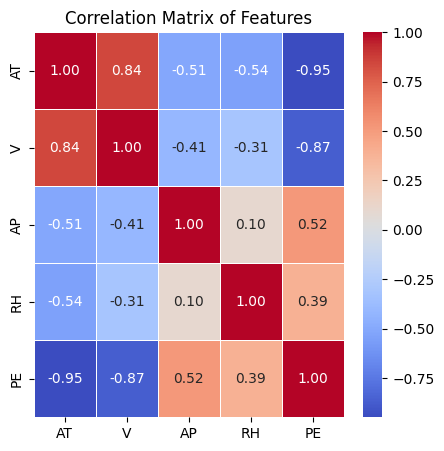

In [8]:
#Correlation matrix - To select features which have Strong Correlation 
corr_matrix = df.corr()
plt.figure(figsize=(5, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.show()

In the dataset, the variables AT and V exhibit a strong negative correlation with the target variable, PE. 

On the other hand, AP and RH show a weaker positive correlation with PE.

In [52]:
'''
# Scatter plot with regression line for AT vs PE
sns.jointplot(x='AT', y='PE', data=df, kind='scatter', height=7)
plt.show()

# Scatter plot with regression line for V vs PE
sns.jointplot(x='V', y='PE', data=df, kind='scatter', height=7)
plt.show()
'''
# To check the relationship between two features AT and V with respect to PE

"\n# Scatter plot with regression line for AT vs PE\nsns.jointplot(x='AT', y='PE', data=df, kind='scatter', height=7)\nplt.show()\n\n# Scatter plot with regression line for V vs PE\nsns.jointplot(x='V', y='PE', data=df, kind='scatter', height=7)\nplt.show()\n"

Defined features and target

In [10]:
df_1 =  df['AT']        #didn't used in train_test_split because it's expected a 2D array
df_2 = df[['AT','V']]
df_3 = df[['AT','V','AP']]
df_4 = df[['AT','V','AP','RH']] 

Split Dataset into train and test --- ( 80% -> train  and 20% -> test )

In [60]:
X_train,X_test,y_train,y_test = train_test_split(df_4,y,test_size=0.2,random_state=0)

Model used - Linear Regression

In [61]:
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [90]:
#used ridge regression model which is a linear regression model with L2 regularization - same result linear regression
'''
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
'''

'\nfrom sklearn.linear_model import Ridge\n\nridge = Ridge(alpha=1.0)\nridge.fit(X_train, y_train)\n'

Model used - Random Forest Regressor

Random Forest can be used for regression problems as well as classification problems. In the context of regression, it's called Random Forest Regression or Random Forest Regressor.

Random Forest Regressor works by building multiple decision trees during training and outputting the mean prediction of the individual trees for regression tasks.



In [93]:
from sklearn.ensemble import RandomForestRegressor
rf= RandomForestRegressor()
rf.fit(X_train, y_train)

RandomForestRegressor()

In [94]:
#Predicting on test dataset - Random forest 
y_pred = rf.predict(X_test)

In [87]:
#Predicting on test dataset - Linear Regression
y_pred = regressor.predict(X_test)

Root Mean Square Error - lower the score the better

In [95]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rmse

### Simple Linear Regression Results ###
#with df_2 = 4.848
#with df_3 = 4.782
#with df_4 = 4.442


### Random forest results ###
#with df_4 = 3.201

3.2011886161951892

R- Squared - higher the score the better

In [96]:
r_squared = r2_score(y_test, y_pred)
r_squared

### Simple Linear Regression Results ###
#with df_2 = 0.9196
#with df_3 = 0.9218
#with df_4 = 0.9325


### Random forest results ###
#with df_4 = 0.9649

0.9649639837538645

Yes, I effectively interpreted and communicated the performance of my model using metrics such as R^2 score and mean squared error. Incorporating all available features improved the model's predictive power and provided a comprehensive insight into its performance.